In [ ]:
# 09/01
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

cuda
NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
import torch

def test_installation():
    print('PyTorch Version:{torch.__version__}')
    if torch.cuda.is_available():
        print('CUDA is available. GPU를 사용합니다.')
        print(f'사용 가능한 GPU 개수: {torch.cuda.device_count()}')
        print(f'현재 GPU 이름: {torch.cuda.get_device_name(0)}')
    else:
        print('CUDA를 사용할 수 없습니다. CPU 모드로 실행합니다.')

test_installation()

PyTorch Version:{torch.__version__}
CUDA is available. GPU를 사용합니다.
사용 가능한 GPU 개수: 1
현재 GPU 이름: NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
def conditional_function(x):
    """조건부 함수: x > 0이면 x², x ≤ 0이면 |x|"""
    # 동적 그래프의 핵심: 런타임에 조건 판단!
    if x > 0:
        return x ** 2
    else:
        return torch.abs(x)

for val in [-3.0, -1.0, 0.0, 1.0, 3.0]:
    x = torch.tensor(val, requires_grad=True)
    y = conditional_function(x)
    y.backward()
    print(f"x={val:4.1f} → y={y.item():5.2f}, dy/dx={x.grad.item():5.2f}")

x=-3.0 → y= 3.00, dy/dx=-1.00
x=-1.0 → y= 1.00, dy/dx=-1.00
x= 0.0 → y= 0.00, dy/dx= 0.00
x= 1.0 → y= 1.00, dy/dx= 2.00
x= 3.0 → y= 9.00, dy/dx= 6.00


In [5]:
import torch

def main():
    # 간단한 텐서 생성 및 출력
    x = torch.tensor([1.0, 2.0, 3.0])
    print('Hello, PyTorch!')
    print(f'Tensor x: {x}')

main()

Hello, PyTorch!
Tensor x: tensor([1., 2., 3.])


In [40]:
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

a_cpu = torch.randn(1000, 1000)
b_cpu = torch.randn(1000, 1000)

start_time = time.time()
c_cpu = torch.matmul(a_cpu, b_cpu)
cpu_time = time.time() - start_time
print(f'CPU 연산 시간: {cpu_time:.4f}초')

if torch.cuda.is_available():
    a_gpu = a_cpu.to(device)
    b_gpu = b_cpu.to(device)

    start_time = time.time()
    c_gpu = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()   # GPU 연산 완료 대기
    gpu_time = time.time() - start_time
    print(f'속도 향상: {cpu_time/gpu_time:.1f}배 빨라짐!')

CPU 연산 시간: 0.0056초
속도 향상: 15.1배 빨라짐!


In [60]:
import platform

# Colab(Linux)에서만 나눔고딕 설치 (Windows/Mac은 OS 내장 한글 폰트를 사용하므로 불필요)
if platform.system() == 'Linux':
    !apt -qq -y install fonts-nanum

In [61]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

system = platform.system()
if system == 'Windows':
    # Windows는 맑은 고딕이 기본 내장되어 있어 설치 없이 바로 사용 가능
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    # macOS 기본 내장 한글 폰트
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 Linux: 위 셀에서 설치한 나눔고딕을 등록
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 설정한 폰트가 실제로 잡혔는지 확인
print('적용된 폰트:', plt.rcParams['font.family'])


적용된 폰트: ['Malgun Gothic']


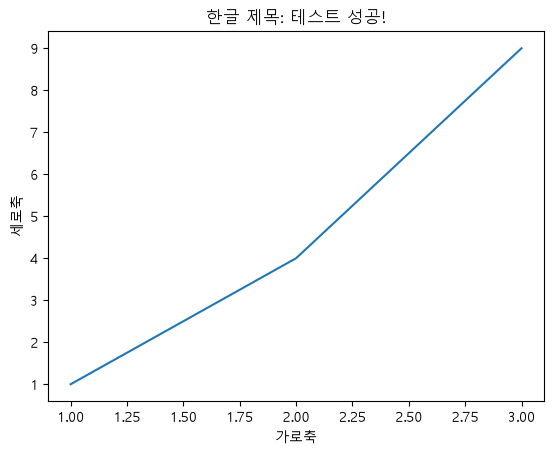

In [59]:
plt.figure()
plt.title("한글 제목: 테스트 성공!")
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

In [ ]:
# (1) 리스트나 배열로부터 직접 생성
tensor1d = torch.tensor([1, 2, 3])
tensor2d = torch.tensor([[1, 2, 3],
                         [4, 5, 6]])

# (2) 특수 함수로 생성
zeros_tensor = torch.zeros((3, 3))      # 전부 0
ones_tensor  = torch.ones((2, 4))       # 전부 1
full_tensor  = torch.full((2, 2), 7)    # 전부 7

arange_tensor   = torch.arange(0, 10, step=2)    # 0,2,4,6,8
linspace_tensor = torch.linspace(0, 1, steps=5)  # 0, .25, .5, .75, 1

# (3) 무작위 텐서 생성
rand_tensor  = torch.rand((3, 3))    # 0~1 균일 분포
randn_tensor = torch.randn((2, 2))   # 평균 0, 표준편차 1 정규분포

# (4) 데이터 타입 설정
float_tensor = torch.tensor([1, 2, 3], dtype=torch.float32)
int_tensor   = torch.tensor([1, 2, 3], dtype=torch.int64)

# 자료형 변환
float_tensor  = int_tensor.float()   # torch.float32
long_tensor   = int_tensor.long()    # torch.int64
double_tensor = int_tensor.double()  # torch.float64

In [73]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

print(f"a + b = {a + b}")   # tensor([5, 7, 9])
print(f"b - a = {b - a}")   # tensor([3, 3, 3])
print(f"a * b = {a * b}")   # tensor([4, 10, 18])   ← 행렬곱이 아님!
print(f"b / a = {b / a}")   # tensor([4.0000, 2.5000, 2.0000])

# 스칼라와의 연산
print(f"a + 10 = {a + 10}") # tensor([11, 12, 13])
print(f"b * 2 = {b * 2}")   # tensor([8, 10, 12])

a + b = tensor([5, 7, 9])
b - a = tensor([3, 3, 3])
a * b = tensor([ 4, 10, 18])
b / a = tensor([4.0000, 2.5000, 2.0000])
a + 10 = tensor([11, 12, 13])
b * 2 = tensor([ 8, 10, 12])
